# EDA — Personality Type Prediction

**Project step 1 of 3:** `eda.ipynb` → `modeling.ipynb` → `app.py`

This notebook builds on Live Session 1 (`JT_LS1_data_and_pipeline.ipynb`). It keeps the
data loading and the quick look from LS1 and adds the checks the submission asks for:

1. load `data/data.csv` and check its shape and types,
2. look for **missing** and **impossible** values,
3. check how **balanced** the target classes are,
4. look at the **distribution of the personality items**,
5. apply the cleaning decisions in **one place**,
6. save the result as **`data/data_clean.csv`** — the handoff to `modeling.ipynb`.

> The preprocessing **pipeline** (imputing, scaling, one-hot encoding) will live in `modeling.ipynb`. This notebook only *fixes* the data; it does not transform it for a model.

## 1. Load the data

In [1]:
# Setup and package verification
import subprocess
import sys
from pathlib import Path

for pkg in ["gdown", "ipywidgets"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", pkg], check=True)

import gdown
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import textwrap
from IPython.display import HTML, display

FILE_ID = "1lgycXDQapixkoWFxIg48qaYcrNl6uSZM"
DATA_DIR = Path("DATA")
DATA_DIR.mkdir(exist_ok=True)
DATA_FILE = DATA_DIR / "data.csv"

progress = widgets.IntProgress(value=0, min=0, max=100, description="Setup:", bar_style="info")
status = widgets.HTML(value="Starting setup...")
display(progress, status)

progress.value = 20
status.value = "Checking dataset..."

if DATA_FILE.exists():
    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Dataset already available."
else:
    progress.value = 40
    status.value = "Downloading dataset..."
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, output=str(DATA_FILE), quiet=False)
    if not DATA_FILE.exists():
        raise FileNotFoundError(f"Download failed. File not found: {DATA_FILE}")
    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Download complete."

IntProgress(value=0, bar_style='info', description='Setup:')

HTML(value='Starting setup...')

In [2]:
# CSV Setup & Loading
df = pd.read_csv(DATA_FILE)

display(f"Initial data: {len(df)} rows, {df.shape[1]} columns")

'Initial data: 19719 rows, 23 columns'

In [3]:
display(df.head())
display(df.tail())

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
0,1,1,1,1,1,1,2,1,5,5,...,2,53,1,4,5,1,5,Male,Right,Resilient
1,4,2,3,2,2,4,4,3,3,3,...,3,46,2,2,4,5,1,Female,Right,Moderate
2,5,5,5,5,5,5,5,5,1,1,...,4,14,1,5,5,1,5,Female,Right,Moderate
3,5,5,5,5,4,5,4,4,2,4,...,4,19,5,2,4,5,4,Female,Right,Overcontroller
4,3,3,3,3,3,4,3,3,3,3,...,3,25,3,3,5,5,3,Female,Right,Moderate


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
19714,5,4,4,5,4,4,5,4,3,3,...,5,15,3,1,5,5,1,Female,Right,Overcontroller
19715,2,2,2,2,2,2,2,3,2,4,...,3,37,2,2,4,4,4,Female,Right,Resilient
19716,5,5,5,5,5,5,5,5,4,1,...,5,16,5,2,2,5,1,Male,Right,Overcontroller
19717,4,4,4,4,4,4,5,4,2,3,...,3,16,2,1,4,5,4,Male,Right,Overcontroller
19718,3,3,4,5,2,4,5,3,1,2,...,5,35,4,2,3,4,2,Male,Right,Overcontroller


In [4]:
counts = df["target"].value_counts()

target_overview = pd.DataFrame({
    "count": counts,
    "share_%": (counts / len(df) * 100).round(1),
})
target_overview.index.name = "personality type"
target_overview

,count,share_%
personality type,,
Moderate,8452,42.9
Resilient,6163,31.3
Overcontroller,2829,14.3
Undercontroller,2275,11.5


# 2. Target Analysis (y)

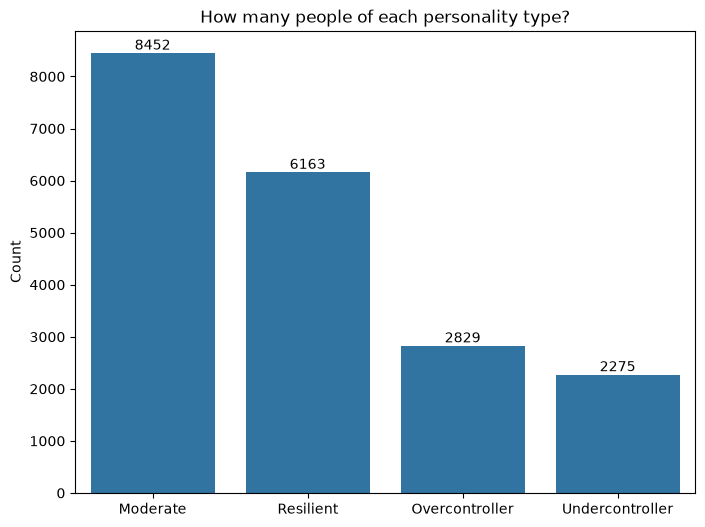

In [5]:
# What are we predicting? The personality type.
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x="target", order=df["target"].value_counts().index)
ax.bar_label(ax.containers[0])  # shows the count on each bar

plt.title("How many people of each personality type?")
plt.xlabel("")
plt.ylabel("Count")
plt.show()


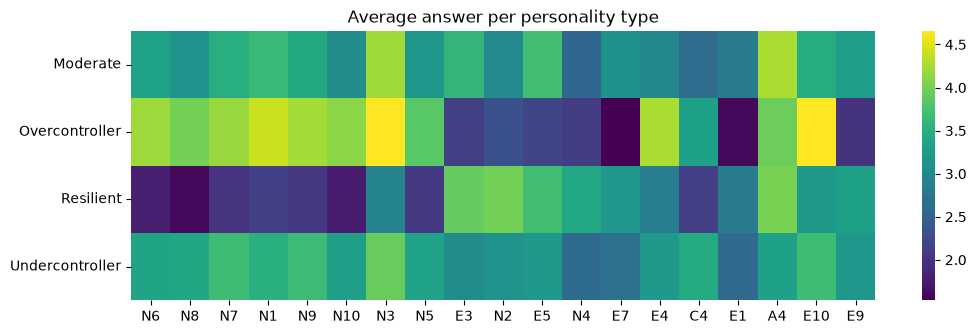

In [6]:
# The personality questions = every column except the demographics and target
item_cols = [c for c in df.columns if c not in ["age", "gender", "hand", "target"]]

# Average answer to each question, per personality type.
# This is the kind of signal the model will learn from.
plt.figure(figsize=(12, 3.5))
sns.heatmap(df.groupby("target")[item_cols].mean(), cmap="viridis")
plt.title("Average answer per personality type")
plt.ylabel("")
plt.show()

# Exploratory Data Analysis (EDA)

### 2.1 Structure, data types and missing values

One row = one person. Before modelling we check the column types, gaps and duplicates.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19719 entries, 0 to 19718
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   N6      19719 non-null  int64
 1   N8      19719 non-null  int64
 2   N7      19719 non-null  int64
 3   N1      19719 non-null  int64
 4   N9      19719 non-null  int64
 5   N10     19719 non-null  int64
 6   N3      19719 non-null  int64
 7   N5      19719 non-null  int64
 8   E3      19719 non-null  int64
 9   N2      19719 non-null  int64
 10  E5      19719 non-null  int64
 11  N4      19719 non-null  int64
 12  E7      19719 non-null  int64
 13  E4      19719 non-null  int64
 14  age     19719 non-null  int64
 15  C4      19719 non-null  int64
 16  E1      19719 non-null  int64
 17  A4      19719 non-null  int64
 18  E10     19719 non-null  int64
 19  E9      19719 non-null  int64
 20  gender  19695 non-null  str  
 21  hand    19619 non-null  str  
 22  target  19719 non-null  str  
dtypes: int64(20), str(3)
m

In [8]:
df.describe()

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9
count,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,1.971900e+04,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000
mean,2.980374,2.803235,3.151935,3.262082,3.135250,2.833764,3.842690,2.951722,3.416755,3.234596,3.432223,2.756276,2.867285,3.152036,5.076703e+04,2.654242,2.628937,4.030073,3.585324,3.094275
std,1.320437,1.350648,1.299910,1.308169,1.298573,1.313036,1.138854,1.272889,1.236820,1.177018,1.282003,1.220964,1.431814,1.222822,7.121272e+06,1.243191,1.232565,1.045403,1.304571,1.396490
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.800000e+01,2.000000,2.000000,4.000000,3.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.200000e+01,3.000000,3.000000,4.000000,4.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,3.100000e+01,4.000000,4.000000,5.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000e+09,5.000000,5.000000,5.000000,5.000000,5.000000


In [9]:
# Missing values per column (only columns that have any)
missing = df.isna().sum()
print("Missing values:")
print(missing[missing > 0])
print()
print("Exact duplicate rows (not considering age):", df.duplicated(keep=False).sum()) #can be called suspicious duplicates, as they have the same answers to all questions and the same demographics except for age. This could be a data entry error or a case of multiple people with the same answers and demographics except for age.
df[df.duplicated()]

Missing values:
gender     24
hand      100
dtype: int64

Exact duplicate rows (not considering age): 6


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
13093,5,5,5,5,5,5,5,5,5,5,...,5,21,5,5,5,5,5,Male,Right,Moderate
16591,5,5,5,5,5,5,5,5,5,5,...,5,18,5,5,5,5,5,Male,Right,Moderate
17685,5,5,5,5,5,5,5,5,5,5,...,5,23,5,5,5,5,5,Male,Right,Moderate


### 2.2 The question scores

The instructions say every answer is on a 1–5 scale. Let's check if this is really true.

In [10]:
df[item_cols].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
N6,2.98,1.32,0.0,5.0
N8,2.80,1.35,0.0,5.0
N7,3.15,1.30,0.0,5.0
N1,3.26,1.31,0.0,5.0
N9,3.14,1.30,0.0,5.0
N10,2.83,1.31,0.0,5.0
N3,3.84,1.14,0.0,5.0
N5,2.95,1.27,0.0,5.0
E3,3.42,1.24,0.0,5.0
N2,3.23,1.18,0.0,5.0


Are any answers outside the 1-5 scale?

In [11]:
out_of_range = (df[item_cols] < 1) | (df[item_cols] > 5)
print("Answers outside 1-5:", out_of_range.sum().sum())
print("Rows affected:     ", out_of_range.any(axis=1).sum())
df[out_of_range.any(axis=1)]

Answers outside 1-5: 19
Rows affected:      1


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
19064,0,0,0,0,0,0,0,0,0,0,...,0,52,0,0,0,0,0,Female,Right,Resilient


A total of 19 columns (in one row) have at least one 0 answer that is out of scale. One person answered all out of scale and should be removed along with the other blank rows later.

How are the answers distributed?

Share of people giving each answer, per question.

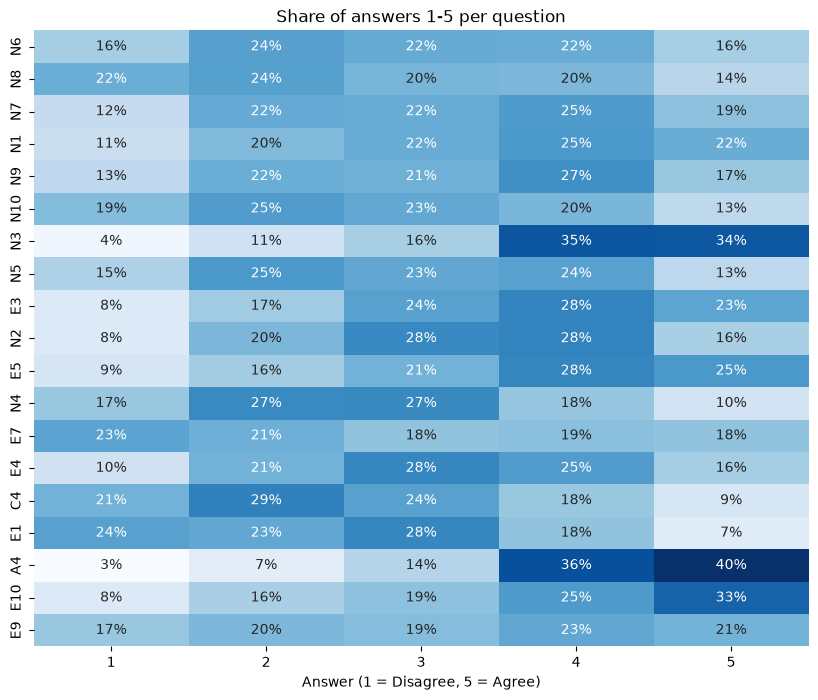

In [12]:
answer_share = (
    df[item_cols]
    .apply(lambda col: col.value_counts(normalize=True))
    .reindex([1, 2, 3, 4, 5])
    .T
)

plt.figure(figsize=(10, 8))
sns.heatmap(answer_share, annot=True, fmt=".0%", cmap="Blues", cbar=False)
plt.title("Share of answers 1-5 per question")
plt.xlabel("Answer (1 = Disagree, 5 = Agree)")
plt.show()

### 2.3 Correlations between the questions

The column names tell us which OCEAN trait a question belongs to (N = Neuroticism, E = Extraversion,
C = Conscientiousness, A = Agreeableness).

The 19 items are not spread evenly across the traits. Ten measure Neuroticism and seven Extraversion, but Conscientiousness and Agreeableness have only one item each (C4, A4). Since Undercontroller is defined precisely by C and A, the information needed to spot that type is largely missing from the data. This explains directly why the model only catches ~20% of Undercontrollers while getting most of the Resilients.

In [13]:
# Count of questions per trait
pd.Series([c[0] for c in item_cols]).value_counts().rename({"N": "Neuroticism", "E": "Extraversion", "C": "Conscientiousness", "A": "Agreeableness"})

Neuroticism          10
Extraversion          7
Conscientiousness     1
Agreeableness         1
Name: count, dtype: int64

### Every question against the personality type

A `countplot` per column, split by `target`. For each answer (1–5) we see how the four
personality types are distributed. Where the coloured blocks shift from left to right
between the types, that question separates them — that is the signal the model will learn.

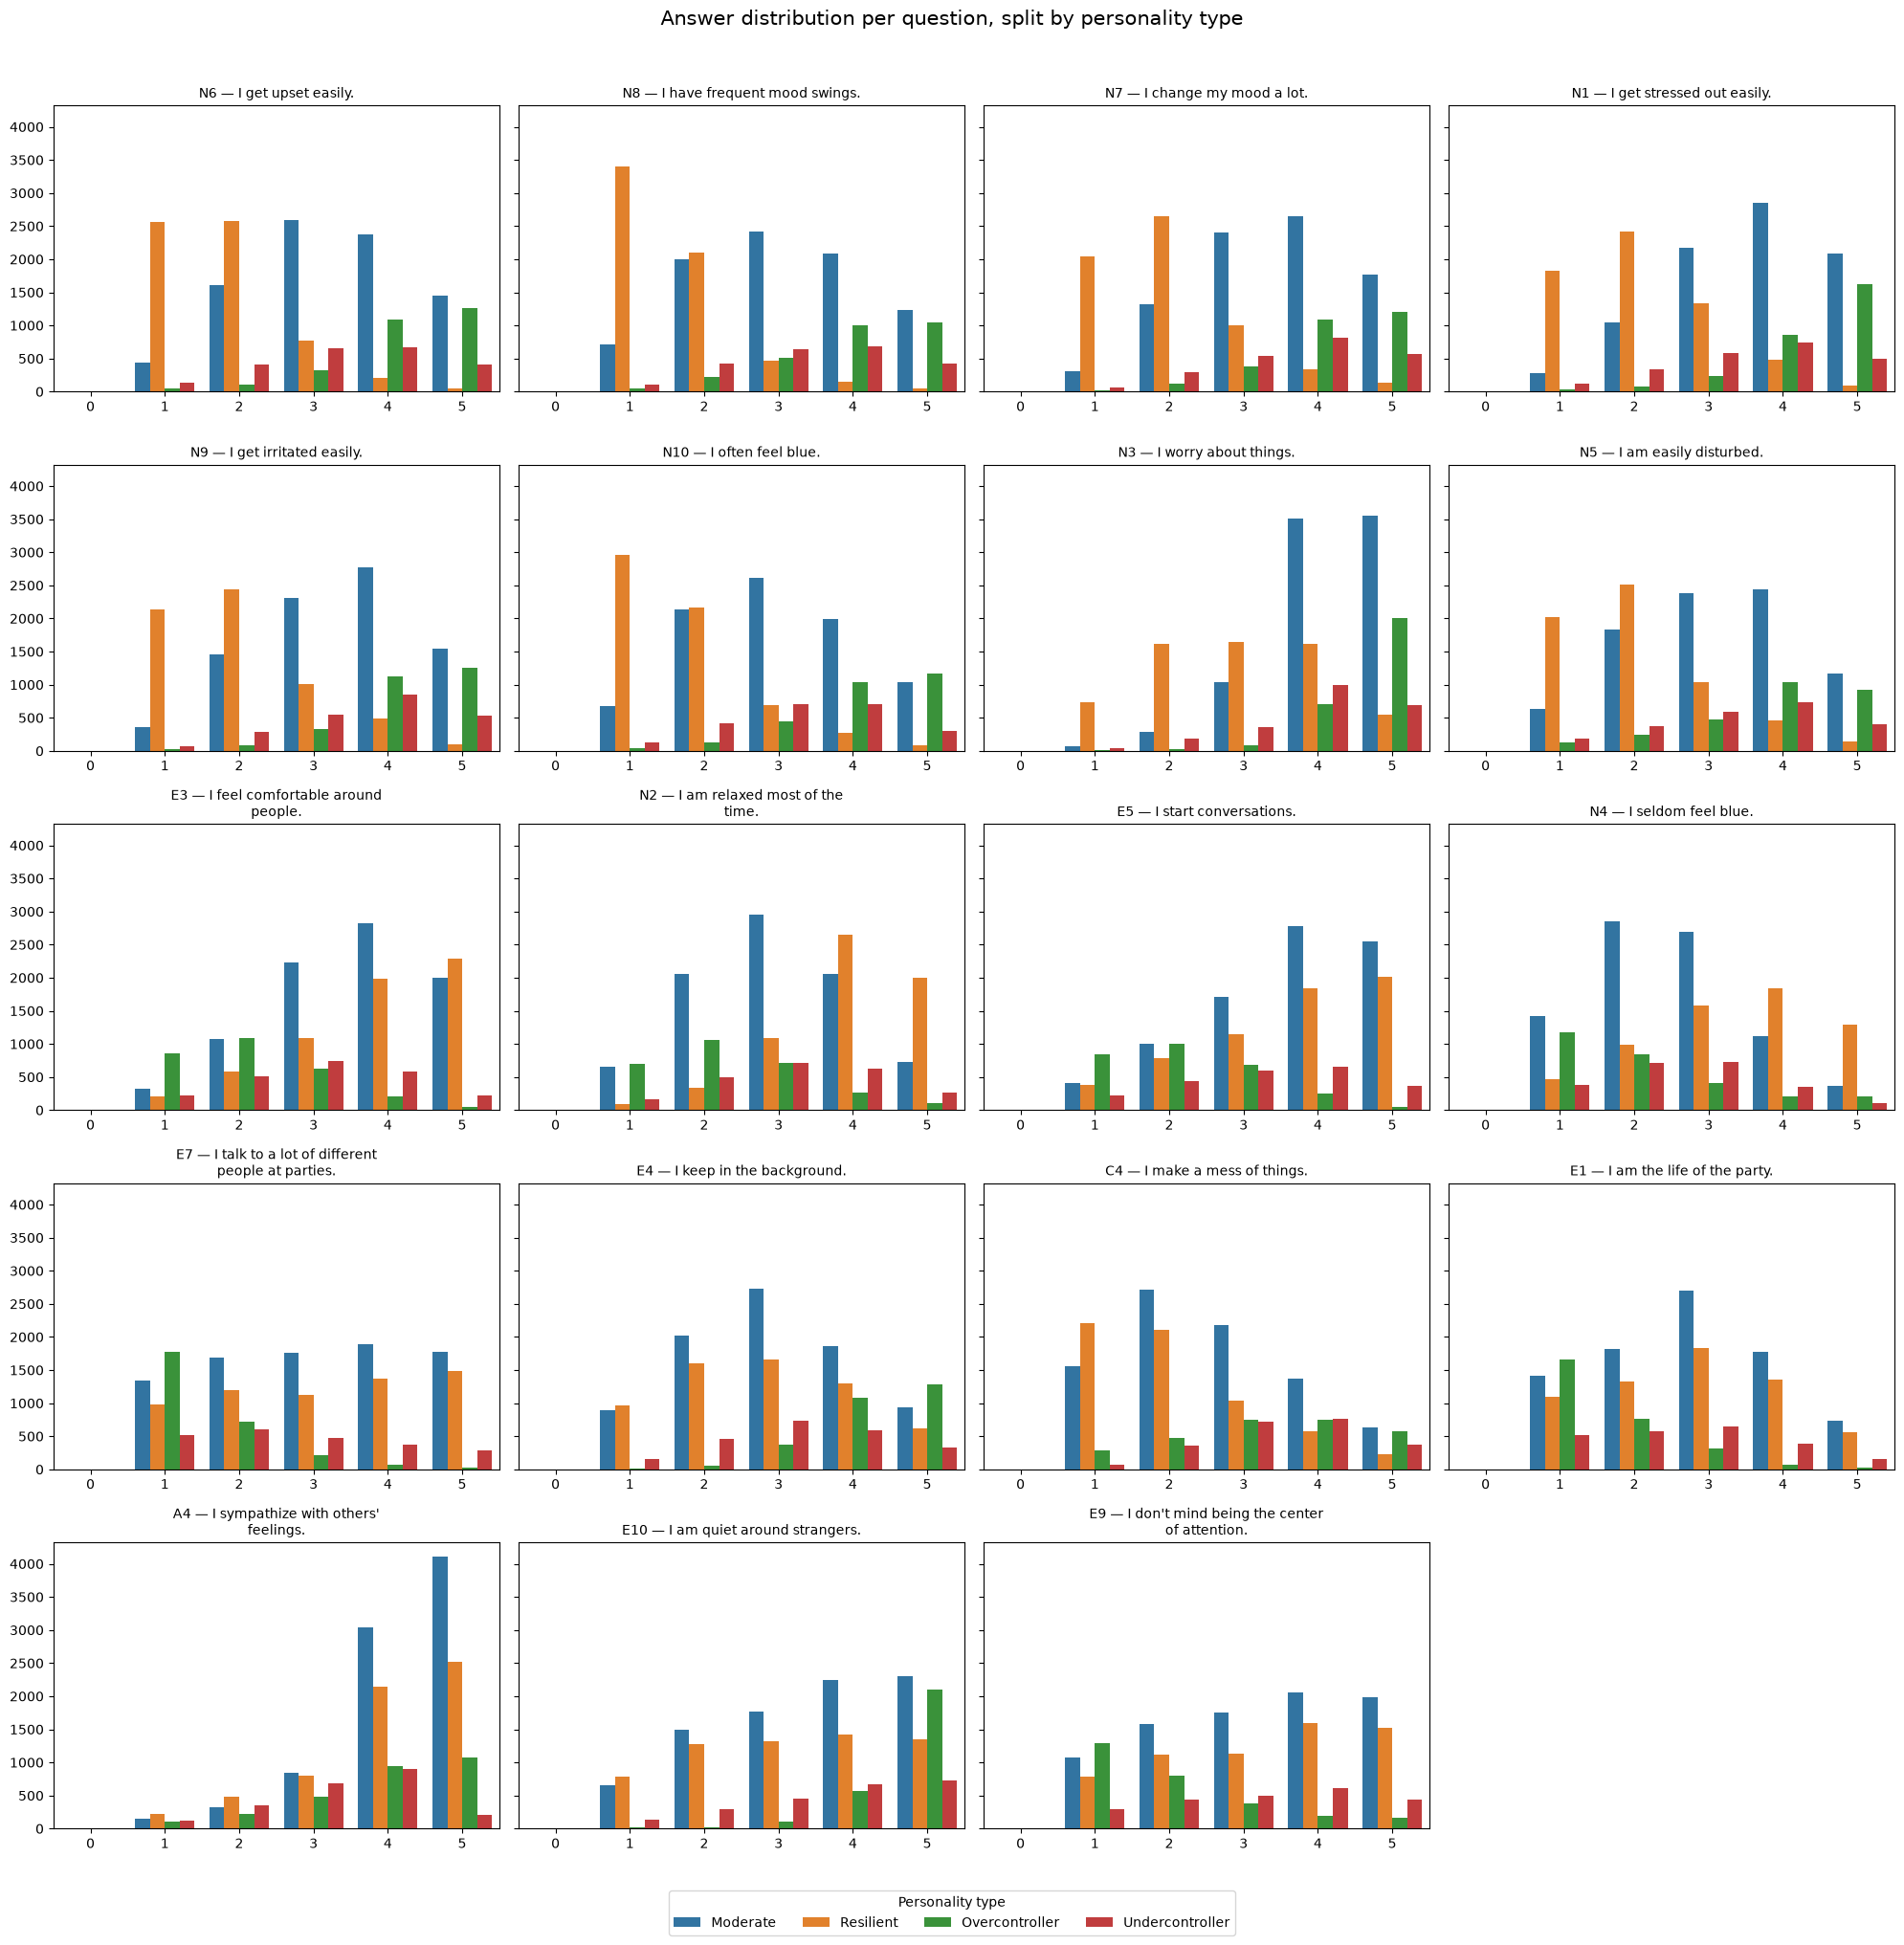

In [14]:
import textwrap
item_labels = {
    "N1":  "I get stressed out easily.",
    "N2":  "I am relaxed most of the time.",
    "N3":  "I worry about things.",
    "N4":  "I seldom feel blue.",
    "N5":  "I am easily disturbed.",
    "N6":  "I get upset easily.",
    "N7":  "I change my mood a lot.",
    "N8":  "I have frequent mood swings.",
    "N9":  "I get irritated easily.",
    "N10": "I often feel blue.",
    "E1":  "I am the life of the party.",
    "E3":  "I feel comfortable around people.",
    "E4":  "I keep in the background.",
    "E5":  "I start conversations.",
    "E7":  "I talk to a lot of different people at parties.",
    "E9":  "I don't mind being the center of attention.",
    "E10": "I am quiet around strangers.",
    "C4":  "I make a mess of things.",
    "A4":  "I sympathize with others' feelings.",
}

order = df["target"].value_counts().index
n, ncols = len(item_cols), 4
nrows = -(-n // ncols)          # round up

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), sharey=True)

for i, (ax, col) in enumerate(zip(axes.flat, item_cols)):
    # only the first plot draws a legend — we reuse its colours for the whole grid
    sns.countplot(data=df, x=col, hue="target", hue_order=order, ax=ax, legend=(i == 0))
    title = f"{col} — {item_labels.get(col, '')}"
    ax.set_title("\n".join(textwrap.wrap(title, 34)), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty axes in the last row
for ax in axes.flat[n:]:
    ax.remove()

# one shared legend for the whole figure
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].get_legend().remove()
fig.legend(handles, labels, title="Personality type",
           loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=4)

fig.suptitle("Answer distribution per question, split by personality type", fontsize=15, y=1.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.985])
plt.show()

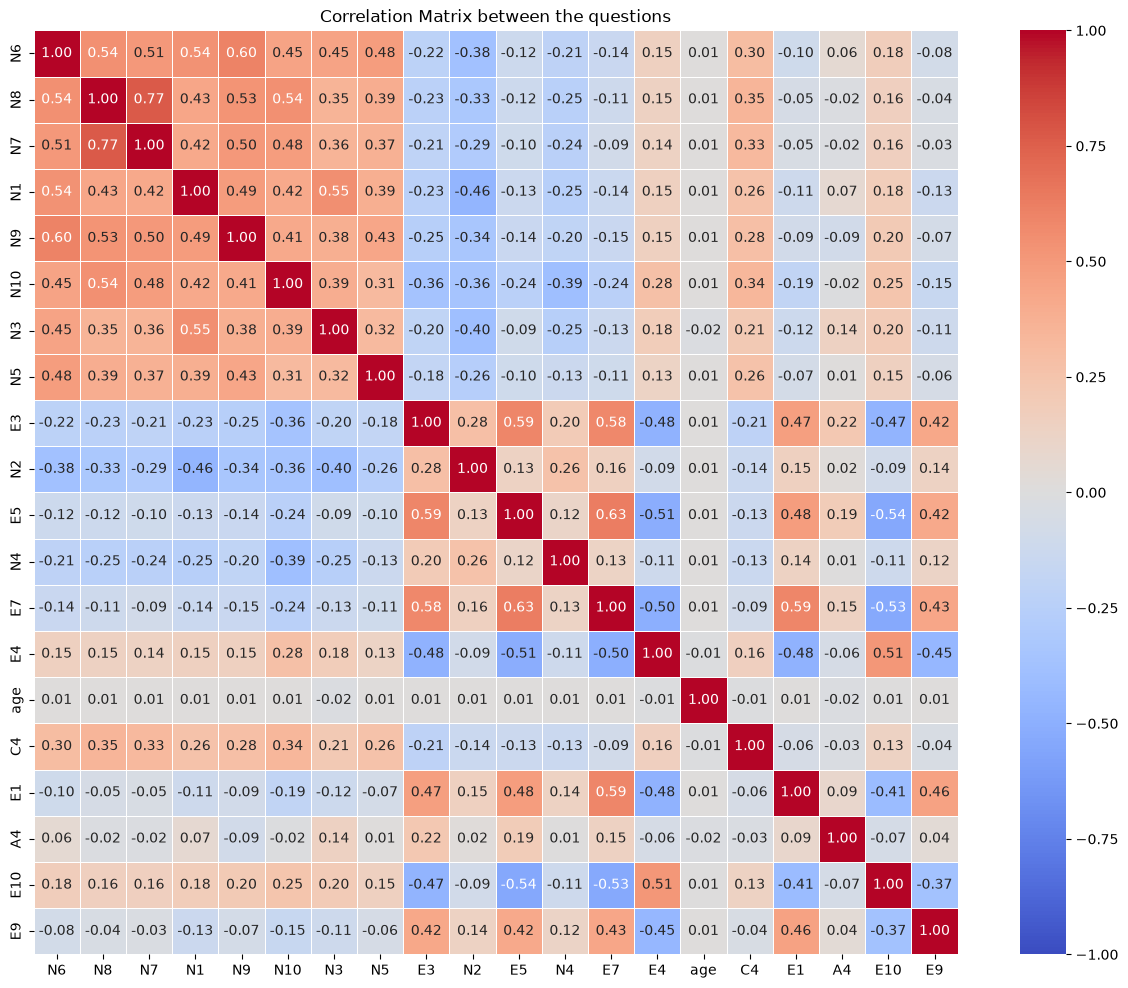


Strongest positive pairs:


N8  N7    0.77
E5  E7    0.63
N6  N9    0.60
E3  E5    0.59
E7  E1    0.59
dtype: float64


Strongest negative pairs:


E5  E10   -0.54
E7  E10   -0.53
E5  E4    -0.51
E7  E4    -0.50
E4  E1    -0.48
dtype: float64

In [15]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", annot=True,fmt=".2f", vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix between the questions")
plt.show()

# Strongest pairs (each pair only once)
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print("\nStrongest positive pairs:")
display(pairs.sort_values(ascending=False).head(5).round(2))
print()
print("Strongest negative pairs:")
display(pairs.sort_values().head(5).round(2))

### 2.4 Age Analysis — looking for outliers

Age is messy. The maximum is 990,000,000. 83 values are over 100, and several look like birth years that were typed in (1961, 1974, 1984…). The minimum is 13, and about 1,450 people are under 16. We need a rule here, for example treating anything outside a plausible range (say 13–100) as missing or imputing the median.

In [16]:
df["age"].describe().round(1)

count        19719.0
mean         50767.0
std        7121271.9
min             13.0
25%             18.0
50%             22.0
75%             31.0
max      999999999.0
Name: age, dtype: float64

In [17]:
df["age"].value_counts() #shows the number of occurrences of each unique value in the "age" column

age
18      1523
17      1370
19      1259
20      1231
21      1216
        ... 
99         1
191        1
78         1
1964       1
118        1
Name: count, Length: 104, dtype: int64

In [18]:
print("Ages above 100:", (df["age"] > 100).sum())
display("Some of those values:", sorted(df.loc[df["age"] > 100, "age"].unique())[:15])
print("Ages below 13:  ", (df["age"] < 13).sum())
print("Ages 13-15:     ", df["age"].between(13, 15).sum())

Ages above 100: 83


'Some of those values:'

[np.int64(118),
 np.int64(188),
 np.int64(191),
 np.int64(208),
 np.int64(211),
 np.int64(223),
 np.int64(266),
 np.int64(1961),
 np.int64(1964),
 np.int64(1968),
 np.int64(1974),
 np.int64(1976),
 np.int64(1977),
 np.int64(1982),
 np.int64(1984)]

Ages below 13:   0
Ages 13-15:      1456


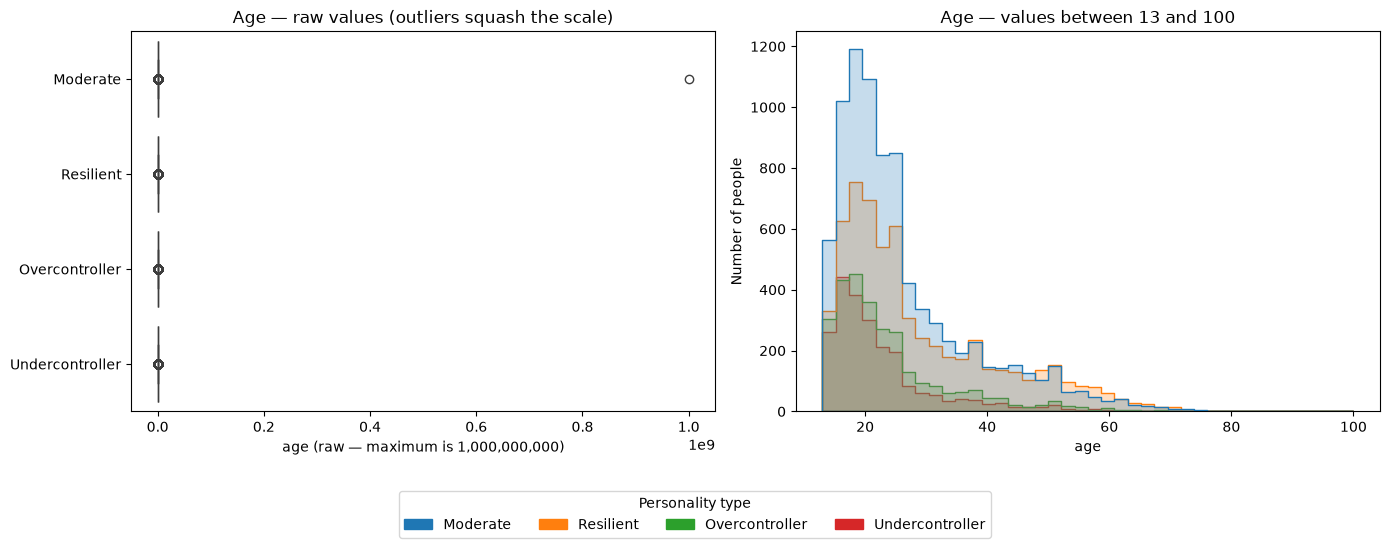

In [19]:
order = df["target"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw values — the extreme outliers squash everything else
sns.boxplot(data=df, x="age", y="target", hue="target",
            order=order, hue_order=order, legend=False, ax=axes[0])
axes[0].set_title("Age — raw values (outliers squash the scale)")
axes[0].set_ylabel("")
axes[0].set_xlabel("age (raw — maximum is 1,000,000,000)")

# Right: plausible range only
plausible = df[df["age"].between(13, 100)]
sns.histplot(data=plausible, x="age", hue="target", hue_order=order,
             bins=40, element="step", ax=axes[1])
axes[1].set_title("Age — values between 13 and 100")
axes[1].set_ylabel("Number of people")
axes[1].get_legend().remove()

# One shared, coloured legend for both panels
handles = [plt.Rectangle((0, 0), 1, 1, color=c)
           for c in sns.color_palette(n_colors=len(order))]
fig.legend(handles, list(order), title="Personality type",
           loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=4)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

We chose the boxenplot because a plain boxplot would just show hundreds of outlier dots on this large data set.

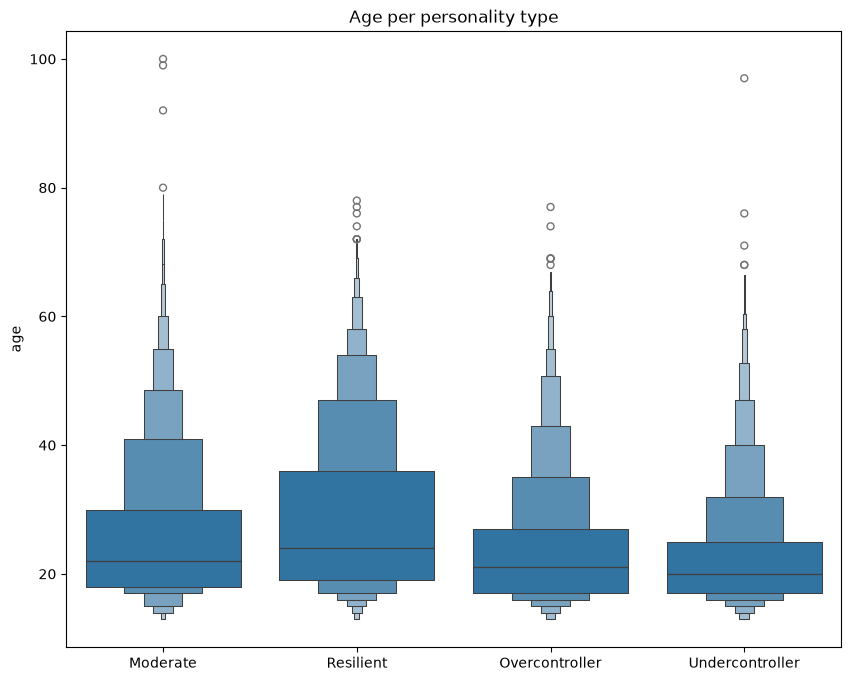

In [20]:
# Does age differ between the personality types? (plausible ages only: 13-100)
plt.figure(figsize=(10, 8))
sns.boxenplot(data=df[df["age"].between(13, 100)], x="target", y="age",
            order=df["target"].value_counts().index)
plt.title("Age per personality type")
plt.xlabel("")
plt.show()

Age is strongly skewed toward young respondents (73 % under 30) in every personality type.

Resilient people with the widest spread (Q3 at 36 vs. 25) are slightly older (median 24) and Undercontrollers slightly younger (median 20), but the distributions overlap so heavily that **age alone barely separates the classes — the predictive signal comes from the questionnaire answers.**

### 2.5 Gender and hand - missing categories

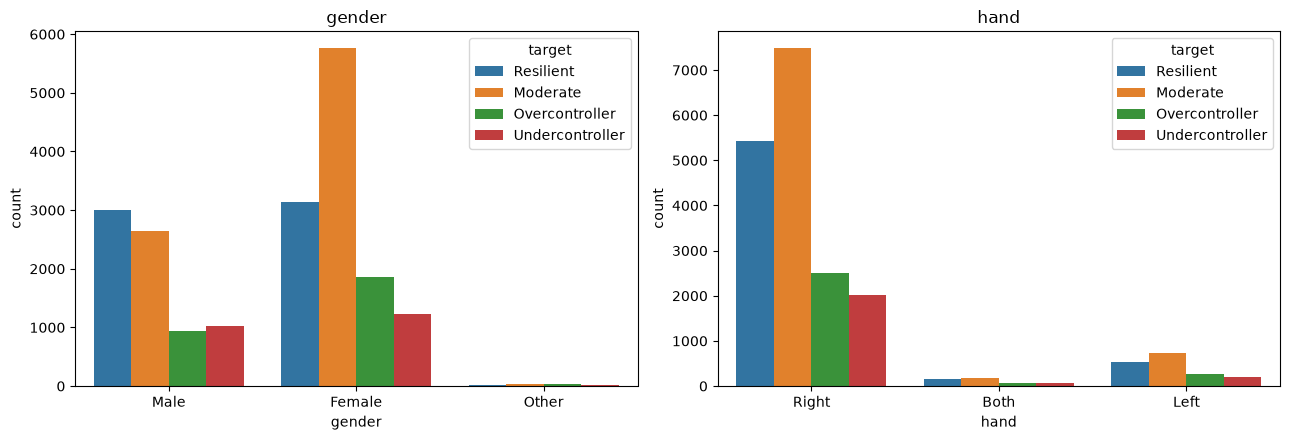

In [21]:
plt.figure(figsize=(13, 4.5))

for i, col in enumerate(["gender", "hand"], start=1):
    plt.subplot(1, 2, i)
    sns.countplot(df, x=col, hue="target")
    plt.title(col)

plt.tight_layout()
plt.show()

124 missing cells across 120 rows (gender 24, hand 100 — so 4 people are missing both)

In [22]:
for col in ["gender", "hand"]:
    print(df[col].value_counts(dropna=False), "\n")
df

gender
Female    11985
Male       7608
Other       102
NaN          24
Name: count, dtype: int64 

hand
Right    17424
Left      1724
Both       471
NaN        100
Name: count, dtype: int64 



,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
0,1,1,1,1,1,1,2,1,5,5,...,2,53,1,4,5,1,5,Male,Right,Resilient
1,4,2,3,2,2,4,4,3,3,3,...,3,46,2,2,4,5,1,Female,Right,Moderate
2,5,5,5,5,5,5,5,5,1,1,...,4,14,1,5,5,1,5,Female,Right,Moderate
3,5,5,5,5,4,5,4,4,2,4,...,4,19,5,2,4,5,4,Female,Right,Overcontroller
4,3,3,3,3,3,4,3,3,3,3,...,3,25,3,3,5,5,3,Female,Right,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19714,5,4,4,5,4,4,5,4,3,3,...,5,15,3,1,5,5,1,Female,Right,Overcontroller
19715,2,2,2,2,2,2,2,3,2,4,...,3,37,2,2,4,4,4,Female,Right,Resilient
19716,5,5,5,5,5,5,5,5,4,1,...,5,16,5,2,2,5,1,Male,Right,Overcontroller
19717,4,4,4,4,4,4,5,4,2,3,...,3,16,2,1,4,5,4,Male,Right,Overcontroller


To see whether the personality split actually differs between groups, we need the shares within each group

In [23]:
# Share of each personality type within each group (rows add up to 1)
for col in ["gender", "hand"]:
    display(pd.crosstab(df[col], df["target"], normalize="index").round(2))

target,Moderate,Overcontroller,Resilient,Undercontroller
gender,,,,
Female,0.48,0.16,0.26,0.10
Male,0.35,0.12,0.39,0.14
Other,0.39,0.31,0.12,0.18


target,Moderate,Overcontroller,Resilient,Undercontroller
hand,,,,
Both,0.40,0.12,0.35,0.13
Left,0.43,0.15,0.31,0.11
Right,0.43,0.14,0.31,0.12


Nearly identical rows — so hand tells you basically nothing. Gender does differ (Resilient is 39% among men vs. 26% among women).

### 2.6 Key findings from the EDA

- **Size:** 19,719 people, 23 columns — 19 question scores, `age`, `gender`, `hand` and the `target`.
- **Imbalanced classes:** Moderate ≈ 43 %, Resilient ≈ 31 %, Overcontroller ≈ 14 %, Undercontroller ≈ 12 %.
  A model that always says "Moderate" would already get ~43 % accuracy, so accuracy alone can be misleading.
- **The questions carry clear signal:** the Neuroticism questions (N…) separate Resilient (low answers) from Overcontroller (high answers). Some Extraversion questions correlate *negatively* with others —
  these are reverse-worded questions, which is fine for the models.
- **Invalid answers:** one row has `0` for all 19 questions. `0` is not on the 1–5 scale (in the original Kaggle data it means "not answered"), so this row is dropped.
- **Age has impossible values:** a maximum of 999,000,000, 83 ages above 100 — 73 of the 83 implausible ages look like birth years that were typed in; we removed them rather than guess the survey year. Median imputation would **not** fix these, and they would distort the scaling.
- **Missing values:** `gender` (24) and `hand` (100) — small, they are removed and the pipeline's imputer can handle them in the future.
- **Duplicates:** 3 "duplicate" (suspicious) rows (in all numerical questions except age). They have different ages (so not true dupes) but make no logical sense as the same rating in every class is partially contradicting.
- **Gender** shows some differences between types (e.g. more Resilient among men), **hand** hardly any.

## 2b. Clean the data before modelling

The pipeline fills gaps, but it cannot tell that an age of 999,000,000 is wrong. So we remove the problems found above **before** splitting into X and y. Every row is deleted where:

- all numerical columns have the exact same answer (see cell 68)
- an answer is `0`, because that is outside the allowed range of 1–5
- `hand` is empty
- `gender` is empty
- `age` is above 100 or below 13 — impossible values

In the Streamlit app the inputs are restricted (sliders 1–5, age 13–100, required dropdowns), so a new user cannot enter these kinds of values.

In [24]:
AGE_MIN, AGE_MAX = 13, 100

rows_before = len(df)
cleaning_log = []

def log(step, df):
    """Record how many rows this step removed."""
    previous = cleaning_log[-1][2] if cleaning_log else rows_before
    cleaning_log.append((step, previous - len(df), len(df)))

# 1. Exact duplicate rows
df = df.drop_duplicates()
log("1. Duplicate rows", df)

# 2. Answers outside the 1-5 scale (0 = "not answered" in the original data)
df = df[df[item_cols].isin([1, 2, 3, 4, 5]).all(axis=1)]
log("2. Answers outside 1-5", df)

# 3. Missing demographics
df = df.dropna(subset=["gender", "hand"])
log("3. Missing gender / hand", df)

# 4. Impossible ages
df = df[df["age"].between(AGE_MIN, AGE_MAX)]
log(f"4. Age outside {AGE_MIN}-{AGE_MAX}", df)

df = df.reset_index(drop=True)

# Overview: how many rows did each step remove?
summary = pd.DataFrame(cleaning_log, columns=["step", "rows_removed", "rows_left"])
display(summary)

print("Rows before:", rows_before)
print("Rows after: ", len(df))
print("Removed:    ", rows_before - len(df),
      f"({(rows_before - len(df)) / rows_before:.1%})")
print("\nMissing values left:", df.isna().sum().sum())
display(df["age"].describe().round(1))

,step,rows_removed,rows_left
0,1. Duplicate rows,3,19716
1,2. Answers outside 1-5,1,19715
2,3. Missing gender / hand,120,19595
3,4. Age outside 13-100,81,19514


Rows before: 19719
Rows after:  19514
Removed:     205 (1.0%)

Missing values left: 0


count    19514.0
mean        26.2
std         11.5
min         13.0
25%         18.0
50%         22.0
75%         31.0
max        100.0
Name: age, dtype: float64

We lose 205 rows, about 1%, and end at 19,514 with the implausible age deletion. The class balance barely moves (42.8 / 31.3 / 14.4 / 11.5), so nothing is distorted.

### Saving a cleaned up data_cleaned.csv file

In [25]:
from pathlib import Path 

Path('data').mkdir(parents=True, exist_ok=True) # creates a directory if it does not exist yet
df.to_csv("data/data_cleaned.csv", index=False) # saves the cleaned data to a CSV file

In [26]:
print(Path().resolve()) # prints the absolute path of the current working directory

C:\Users\jackl\OneDrive\Attachments\Desktop\Masterschool\Machine Learning\MLProject\big-five-personality
